## pipeline使用微调过的模型

In [1]:
%matplotlib inline

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import pipeline

### 1. pipeline使用微调的模型

In [2]:
model_name_or_path = "../../../models/train/emotion/model-classfication"

In [3]:
!ls {model_name_or_path}

config.json             special_tokens_map.json tokenizer_config.json
model.safetensors       tokenizer.json          vocab.txt


In [4]:
p = pipeline("text-classification", model=model_name_or_path)

In [5]:
text = "I love python and transformer."
p(text)

[{'label': 'LABEL_1', 'score': 0.7246337532997131}]

In [6]:
p(text, top_k=1)

[{'label': 'LABEL_1', 'score': 0.7246337532997131}]

In [7]:
p(text, top_k=6)

[{'label': 'LABEL_1', 'score': 0.7246337532997131},
 {'label': 'LABEL_2', 'score': 0.20950421690940857},
 {'label': 'LABEL_0', 'score': 0.026074692606925964},
 {'label': 'LABEL_3', 'score': 0.019894635304808617},
 {'label': 'LABEL_5', 'score': 0.012501153163611889},
 {'label': 'LABEL_4', 'score': 0.007391527760773897}]

In [8]:
preds = p(text, top_k=6)

In [9]:
preds

[{'label': 'LABEL_1', 'score': 0.7246337532997131},
 {'label': 'LABEL_2', 'score': 0.20950421690940857},
 {'label': 'LABEL_0', 'score': 0.026074692606925964},
 {'label': 'LABEL_3', 'score': 0.019894635304808617},
 {'label': 'LABEL_5', 'score': 0.012501153163611889},
 {'label': 'LABEL_4', 'score': 0.007391527760773897}]

In [10]:
# 根据key排序
preds = sorted(preds, key=lambda item: item["label"])
preds

[{'label': 'LABEL_0', 'score': 0.026074692606925964},
 {'label': 'LABEL_1', 'score': 0.7246337532997131},
 {'label': 'LABEL_2', 'score': 0.20950421690940857},
 {'label': 'LABEL_3', 'score': 0.019894635304808617},
 {'label': 'LABEL_4', 'score': 0.007391527760773897},
 {'label': 'LABEL_5', 'score': 0.012501153163611889}]

In [11]:
# 把预测的值，转换为pandas
preds_df = pd.DataFrame(preds)
preds_df

,label,score
0,LABEL_0,0.026075
1,LABEL_1,0.724634
2,LABEL_2,0.209504
3,LABEL_3,0.019895
4,LABEL_4,0.007392
5,LABEL_5,0.012501


**注意**：返回的标签，并不是从0-5的，需要自己排序一下。

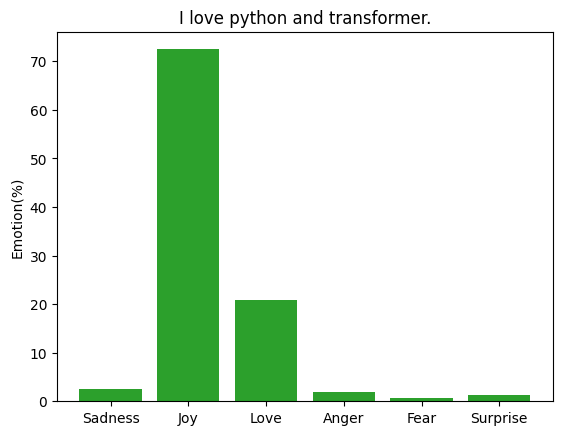

In [12]:
# 画出条形图
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
labels = [l.title() for l in labels]

plt.bar(labels, 100 * preds_df["score"], color='C2')
plt.title(text)
plt.ylabel("Emotion(%)")

plt.show()

### 2. 封装成一个函数且画出条形图

In [13]:
def text_emotion_classifier(text, top_k=6, model=None, color="C4"):
    # 第1步：实例化pipeline
    if not model:
        model = model_name_or_path
        
    p = pipeline("text-classification", model=model)

    # 第2步：执行预测
    preds = p(text, top_k=top_k)
    # 根据key排序
    preds = sorted(preds, key=lambda item: item["label"])

    # 第3步：把预测的结果list转换为DataFrame
    preds_df = pd.DataFrame(preds)

    # 第4步：画图展示
    labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    labels = [l.title() for l in labels]
    
    plt.bar(labels, 100 * preds_df["score"], color=color)
    plt.title(text)
    plt.ylabel("Emotion(%)")
    
    plt.show()

    # 最后返回预测的结果
    return preds_df

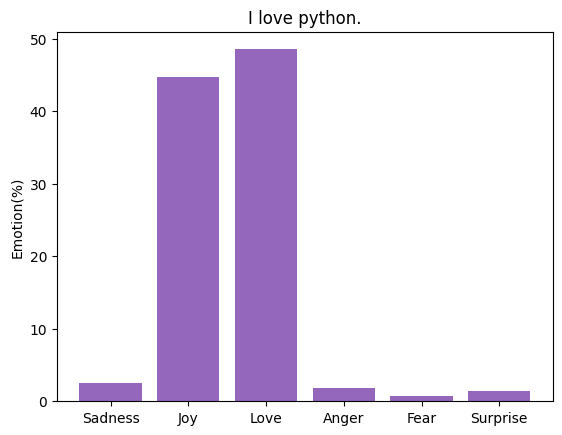

,label,score
0,LABEL_0,0.025858
1,LABEL_1,0.447585
2,LABEL_2,0.485339
3,LABEL_3,0.018912
4,LABEL_4,0.007638
5,LABEL_5,0.014666


In [14]:
text_emotion_classifier("I love python.")

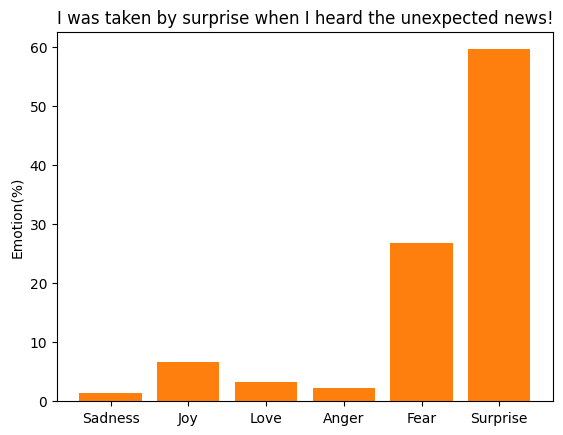

,label,score
0,LABEL_0,0.013413
1,LABEL_1,0.066875
2,LABEL_2,0.033301
3,LABEL_3,0.022209
4,LABEL_4,0.268525
5,LABEL_5,0.595677


In [15]:
text_emotion_classifier("I was taken by surprise when I heard the unexpected news!", color='C1')